In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans # unüberwachte Methode 
from sklearn.datasets import make_blobs # für Beispieldaten


In [3]:
X_b = make_blobs(n_samples=1000, centers=6, random_state=1)
X = X_b[0]
X

array([[ -5.70567118,  -2.89146947],
       [ -0.41605644,   1.20912488],
       [ -9.85546113,  -3.43984307],
       ...,
       [-10.03308043,  -1.84274349],
       [ -0.72018823,   2.59761114],
       [  0.64729936,  -0.32181395]], shape=(1000, 2))

[]

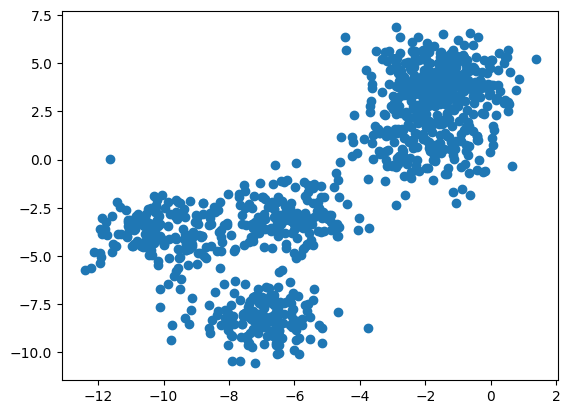

In [8]:
plt.scatter(X[:,0], X[:,1])
plt.plot()

In [26]:
kmeans = KMeans(n_clusters=3, random_state=1) # Durchschnittsbildung über die Punkte 
labels = kmeans.fit_predict(X) # generiere Labels

[]

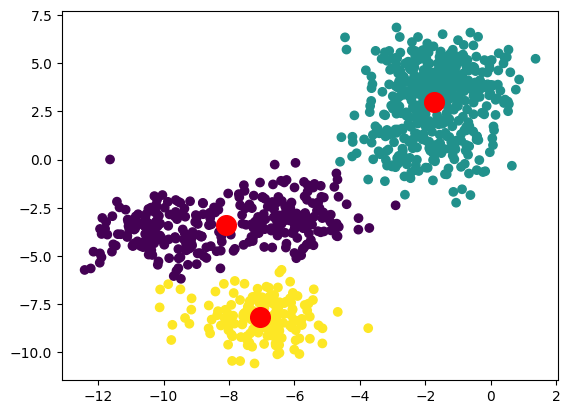

In [ ]:
plt.scatter(X[:,0], X[:,1], c=labels)
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1], c="red", s = 200)
plt.plot()

In [41]:
from sklearn.datasets import load_iris

iris = load_iris()
X=iris.data
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

[]

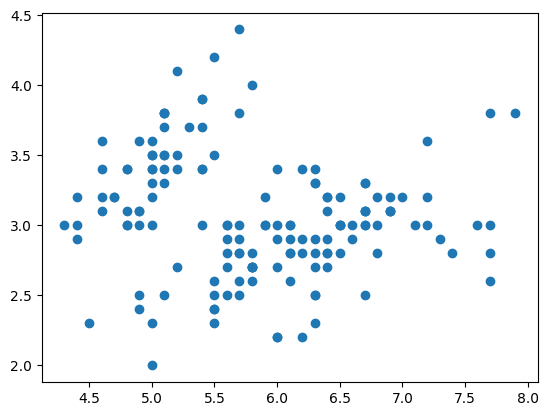

In [42]:
plt.scatter(X[:,0], X[:,1])
plt.plot()

[]

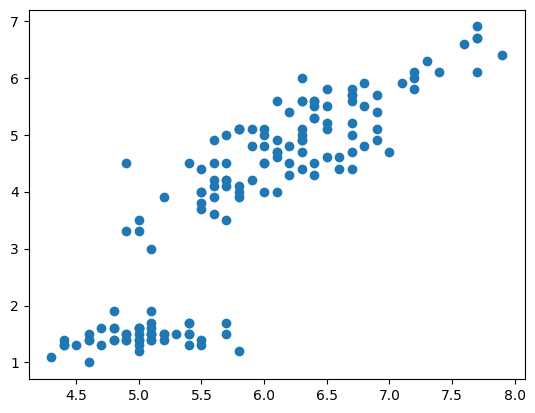

In [33]:
plt.scatter(X[:,0], X[:,2])
plt.plot()

[]

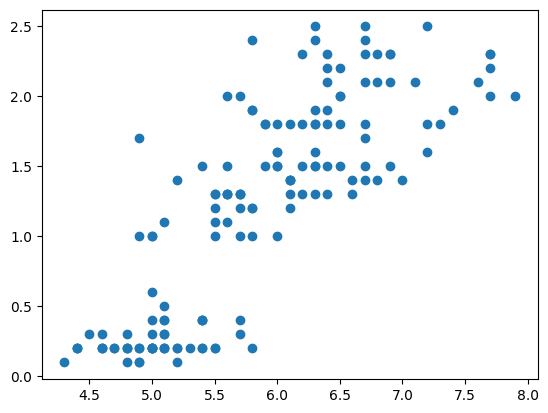

In [35]:
plt.scatter(X[:,0], X[:,3])
plt.plot()

[]

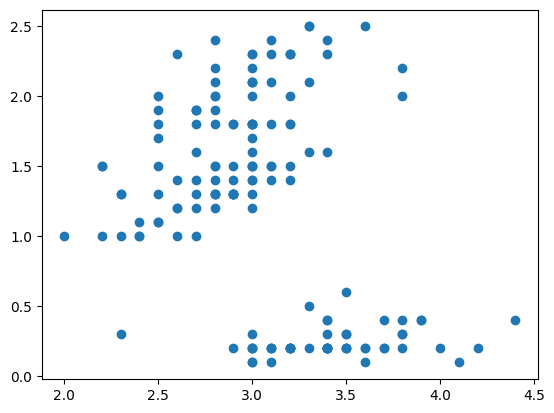

In [37]:
plt.scatter(X[:,1], X[:,3])
plt.plot()

[]

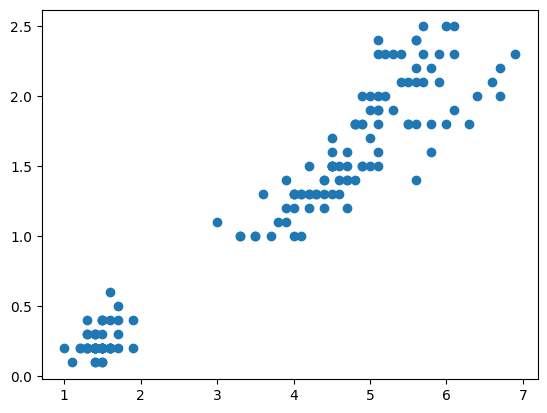

In [39]:
plt.scatter(X[:,2], X[:,3])
plt.plot()

In [58]:
kmeans = KMeans(n_clusters=150, random_state=1)
labels = kmeans.fit_predict(X)

c:\Users\User200\Desktop\KI_Schulung\.venv\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (149) found smaller than n_clusters (150). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


[]

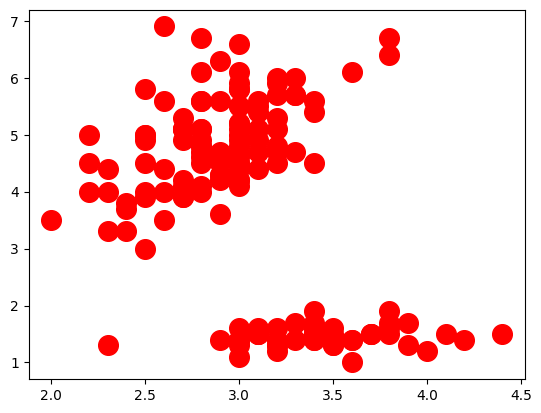

In [59]:
plt.scatter(X[:,1], X[:,2], c=labels)
plt.scatter(kmeans.cluster_centers_[:,1],kmeans.cluster_centers_[:,2], c="red", s = 200)
plt.plot()

In [60]:
kmeans.inertia_ # Verlustfunktionswert 

0.0

In [61]:
# Ellenbogenmethode (Elbow-Method)
from joblib import Parallel, delayed

def run_kmeans(k): 
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(X)
    return (k, kmeans.inertia_) # Anzahl der Cluster und Wert der Verlustfunktion 

In [63]:
# Parallele Iterationen von k=2 bis 3 
results = Parallel(n_jobs=-1)(delayed(run_kmeans)(k) for k in range(2,31)) # -1 = alle Kerne 
results

[(2, 152.34795176035797),
 (3, 78.85566582597727),
 (4, 57.38387326549491),
 (5, 56.16512709030101),
 (6, 42.605791563275446),
 (7, 37.73203557312253),
 (8, 35.57347208931424),
 (9, 34.47646570096573),
 (10, 27.070270895770904),
 (11, 26.29332284382285),
 (12, 24.16666217040016),
 (13, 22.710532133770126),
 (14, 22.21449355907252),
 (15, 20.7824517610013),
 (16, 19.549951761001303),
 (17, 18.54960199230594),
 (18, 17.729726992305945),
 (19, 16.384607028935985),
 (20, 16.032107028935982),
 (21, 14.856369769119778),
 (22, 14.283158730158737),
 (23, 13.361777777777784),
 (24, 13.230134920634924),
 (25, 12.551978354978356),
 (26, 12.290359307359306),
 (27, 12.005359307359306),
 (28, 11.283904761904765),
 (29, 11.009714285714287),
 (30, 10.684630952380953)]

In [64]:
n_k = np.array([i[0] for i in results]) # Cluster
val = np.array([i[1] for i in results]) # Verlustfunktionwert

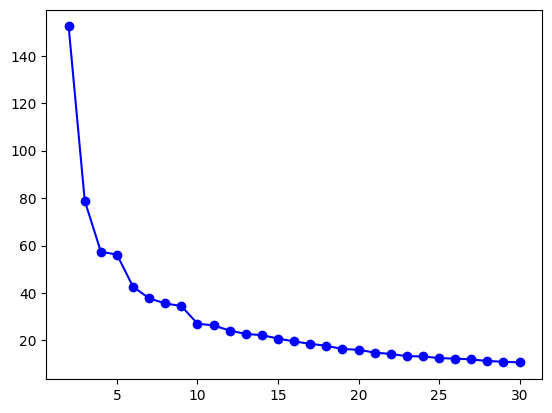

In [65]:
plt.plot(n_k, val, color = "blue", marker = "o")
plt.show()